In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../Data Collection + Processing/data/processed/"

# Phân tích file `training_dataset_labeled.csv`

## Phân tích tổng quan

In [3]:
df_train = pd.read_csv(DATA_PATH + 'training_dataset_labeled.csv')

In [4]:
df_train.head()

,retrieved_at_vn,flight_date,direction,scheduled_time,estimated_time,route_airport,flight_number,status_raw,source_airport,route_airport_std,...,is_wind_variable,scheduled_hour,scheduled_dayofweek,scheduled_month,airline_code,flight_num_only,minutes_to_departure_at_snapshot,is_estimated_missing,temp_dew_spread,is_low_visibility
0,2026-04-09 23:39:16,2026-04-09,Arrival,07:05,06:57,Hà Nội (HAN),QH101,Đúng giờ,DN,HA NOI (HAN),...,1,7,3,4,QH,101,-994.266667,0,4,0.0
1,2026-04-09 23:39:16,2026-04-09,Departure,13:40,13:40,TP. Hồ Chí Minh (SGN),VN129,3-16,DN,HO CHI MINH (SGN),...,1,13,3,4,VN,129,-599.266667,0,4,0.0
2,2026-04-09 23:39:16,2026-04-09,Departure,13:20,13:40,Hà Nội (HAN),9G922,35-39,DN,HA NOI (HAN),...,1,13,3,4,9G,9,-619.266667,0,4,0.0
3,2026-04-09 23:39:16,2026-04-09,Departure,13:20,13:20,Cần Thơ (VCA),VJ703,27-34,DN,CAN THO (VCA),...,1,13,3,4,VJ,703,-619.266667,0,4,0.0
4,2026-04-09 23:39:16,2026-04-09,Departure,13:15,13:15,Hà Nội (HAN),VJ510,27-34,DN,HA NOI (HAN),...,1,13,3,4,VJ,510,-624.266667,0,4,0.0


In [5]:
# Bỏ các cột không có giá trị cho việc EDA
drop_cols = ['retrieved_at_vn', 'report_time_utc', 'report_time_vn', 'raw_metar', 'status_raw', 'route_airport', 'scheduled_time', 
             'estimated_time', 'flight_number']

df_train = df_train.drop(columns=drop_cols)

In [49]:
df_train

,flight_date,direction,source_airport,route_airport_std,status_group,scheduled_dt,estimated_dt,delay_minutes,label_delay,icao_code,...,scheduled_hour,scheduled_dayofweek,scheduled_month,airline_code,flight_num_only,minutes_to_departure_at_snapshot,is_estimated_missing,temp_dew_spread,is_low_visibility,visibility_cat
0,2026-04-09,Arrival,DN,HA NOI (HAN),on_time,2026-04-09 07:05:00,2026-04-09 06:57:00,-8.0,0,VVDN,...,7,3,4,QH,101,-994.266667,0,4,0.0,Normal (>= 5 miles)
1,2026-04-09,Departure,DN,HO CHI MINH (SGN),other,2026-04-09 13:40:00,2026-04-09 13:40:00,0.0,0,VVDN,...,13,3,4,VN,129,-599.266667,0,4,0.0,Normal (>= 5 miles)
2,2026-04-09,Departure,DN,HA NOI (HAN),other,2026-04-09 13:20:00,2026-04-09 13:40:00,20.0,1,VVDN,...,13,3,4,9G,9,-619.266667,0,4,0.0,Normal (>= 5 miles)
3,2026-04-09,Departure,DN,CAN THO (VCA),other,2026-04-09 13:20:00,2026-04-09 13:20:00,0.0,0,VVDN,...,13,3,4,VJ,703,-619.266667,0,4,0.0,Normal (>= 5 miles)
4,2026-04-09,Departure,DN,HA NOI (HAN),other,2026-04-09 13:15:00,2026-04-09 13:15:00,0.0,0,VVDN,...,13,3,4,VJ,510,-624.266667,0,4,0.0,Normal (>= 5 miles)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2126,2026-04-13,Arrival,TSN,HA NOI,unknown,2026-04-13 16:15:00,2026-04-13 16:20:00,5.0,0,VVTS,...,16,0,4,VJ,143,33.700000,0,6,0.0,Normal (>= 5 miles)
2127,2026-04-13,Arrival,TSN,THANH HOA,unknown,2026-04-13 16:15:00,2026-04-13 16:10:00,-5.0,0,VVTS,...,16,0,4,VJ,247,33.700000,0,6,0.0,Normal (>= 5 miles)
2128,2026-04-13,Arrival,TSN,CON DAO,unknown,2026-04-13 16:20:00,2026-04-13 16:25:00,5.0,0,VVTS,...,16,0,4,VN,1896,38.700000,0,6,0.0,Normal (>= 5 miles)
2129,2026-04-13,Arrival,TSN,DA NANG,delayed,2026-04-13 16:25:00,2026-04-13 16:50:00,25.0,1,VVTS,...,16,0,4,VJ,633,43.700000,0,6,0.0,Normal (>= 5 miles)


### Tổng quan dữ liệu

In [6]:
print(f"Số lượng dòng: {df_train.shape[0]}")
print(f"Số lượng cột: {df_train.shape[1]}")
print(df_train.info())

Số lượng dòng: 2131
Số lượng cột: 26
<class 'pandas.DataFrame'>
RangeIndex: 2131 entries, 0 to 2130
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   flight_date                       2131 non-null   str    
 1   direction                         2131 non-null   str    
 2   source_airport                    2131 non-null   str    
 3   route_airport_std                 2131 non-null   str    
 4   status_group                      2131 non-null   str    
 5   scheduled_dt                      2131 non-null   str    
 6   estimated_dt                      2084 non-null   str    
 7   delay_minutes                     2084 non-null   float64
 8   label_delay                       2131 non-null   int64  
 9   icao_code                         2131 non-null   str    
 10  temperature_c                     2131 non-null   int64  
 11  dew_point_c                       2131 non-

### Giá trị bị thiếu

In [7]:
# Liệt kê các cột có giá trị thiếu và tỷ lệ %
missing = df_train.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print(pd.DataFrame({'Số lượng': missing, 'Tỷ lệ (%)': (missing/len(df_train)*100).round(2)}))
else:
    print("Không có giá trị thiếu.")

                    Số lượng  Tỷ lệ (%)
estimated_dt              47       2.21
delay_minutes             47       2.21
wind_direction_deg       135       6.34


$\rightarrow$ cột `wind_direction_deg` thiếu **6%**. Nên kiểm tra xem có cột thiếu này có liên quan đến việc trễ chuyến hay là nhân tố nào không và có các biện pháp điền vào các chỗ thiếu này.

### Dữ liệu trùng lặp

In [8]:
duplicate_count = df_train.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")

Số lượng dòng trùng lặp: 0


### Phân tích các cột Numerical

In [48]:
desc = df_train.describe().T
desc

,count,mean,min,25%,50%,75%,max,std
flight_date,2131,2026-04-11 01:15:40.966682,2026-04-09 00:00:00,2026-04-10 00:00:00,2026-04-11 00:00:00,2026-04-12 00:00:00,2026-04-13 00:00:00,NaN
delay_minutes,2084.0,3.920345,-32.0,0.0,0.0,5.0,425.0,17.355518
label_delay,2131.0,0.149226,0.0,0.0,0.0,0.0,1.0,0.356394
temperature_c,2131.0,28.924449,27.0,28.0,30.0,30.0,30.0,1.237678
dew_point_c,2131.0,24.805725,22.0,25.0,25.0,25.0,25.0,0.582842
wind_direction_deg,1996.0,103.011022,80.0,80.0,110.0,110.0,160.0,18.548909
wind_speed_kt,2131.0,7.058658,2.0,4.0,9.0,9.0,10.0,2.520309
visibility_miles,2131.0,5.730497,3.73,6.0,6.0,6.0,6.0,0.734433
is_wind_variable,2131.0,0.063351,0.0,0.0,0.0,0.0,1.0,0.24365
scheduled_hour,2131.0,13.970436,0.0,10.0,14.0,18.0,23.0,4.950987


- **Outliers**: ở cột `delay_minutes`, giá trị Max là 425 phút trong khi 75% giá trị của cột này đề dưới 5 phút.

- Ở đây ta thấy có 1 feature là `is_low_visibility` đều toàn số 0 vì do đã set logic là biến sẽ = 1 khi `visibility_miles < 3`. Chưa cần phải xoá -> có thể có lợi cho dữ liệu được lấy từ lần sau.

- Bất cập trong thu thập dữ liệu: Cột `minutes_to_departure_at_snapshot` có giá trị âm chiếm đa số (Mean ~ -1140). Điều này cho thấy phần lớn dữ liệu được thu thập sau khi chuyến bay đã khởi hành.
    - Nhận xét: Nếu dùng để dự báo thời gian thực, cần lọc lại chỉ lấy các dòng có giá trị dương (dữ liệu thu thập trước giờ bay).

- Các cột có miền giá trị khác nhau $\rightarrow$ cần scale lại giá trị trước khi đưa vào mô hình

### Phân tích các cột Categorical

In [10]:
categorical_cols = df_train.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    print(f"{col:<18}: {df_train[col].nunique():>4} giá trị khác nhau")

flight_date       :    5 giá trị khác nhau
direction         :    2 giá trị khác nhau
source_airport    :    3 giá trị khác nhau
route_airport_std :   25 giá trị khác nhau
status_group      :    6 giá trị khác nhau
scheduled_dt      :  960 giá trị khác nhau
estimated_dt      : 1442 giá trị khác nhau
icao_code         :    3 giá trị khác nhau
cloud_cover       :    4 giá trị khác nhau
airline_code      :   11 giá trị khác nhau


1. Nhóm Low Cardinality
- `direction`, `source_airport`, `icao_code` có độ đa dạng thấp -> có thể One-hot Encoding

- `airline_code` là số lượng hãng bay được dùng để thay thế cho `flight_number` số hiệu chuyến bay

2. Nhóm dữ liệu thời gian
- `scheduled_dt` (960 giá trị), `estimated_dt` (1442 giá trị) -> Không đưa trực tiếp vào mô hình, sẽ dùng các cột được tách sẵn như `scheduled_hour`. `scheduled_dayofweek` có độ đa dạng thấp và mang tính quy luật hơn.

### Phân tích cột Label

C:\Users\vnviv\AppData\Local\Temp\ipykernel_2960\3213847593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_delay', data=df_train, palette='viridis')


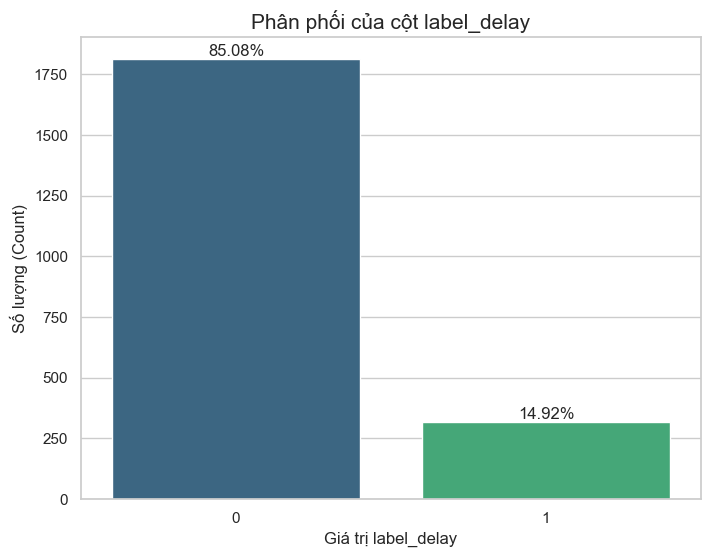

In [55]:
plt.figure(figsize=(8, 6))

# 2. Vẽ biểu đồ countplot (đếm số lượng từng loại)
ax = sns.countplot(x='label_delay', data=df_train, palette='viridis')

# 3. Tính toán phần trăm và hiển thị lên đầu mỗi cột
total = len(df_train['label_delay'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

# 4. Thêm tiêu đề và nhãn
plt.title('Phân phối của cột label_delay', fontsize=15)
plt.xlabel('Giá trị label_delay', fontsize=12)
plt.ylabel('Số lượng (Count)', fontsize=12)

# 5. Hiển thị biểu đồ
plt.show()

$\rightarrow$ Dữ liệu bị mất cân bằng, tỉ lệ trễ (15%) và tỉ lệ đúng giờ (85%)

### Kiểm tra tính Logic

In [13]:
print("--- Kiểm tra tính Logic ---")

# 1. Nhiệt độ không thể thấp hơn điểm sương (vật lý)
physics_error = df_train[df_train['temperature_c'] < df_train['dew_point_c']]
print(f"Số dòng lỗi Nhiệt độ < Điểm sương: {len(physics_error)}")

# 2. Kiểm tra những chuyến bay 'đúng giờ' (label 0) nhưng số phút trễ lại quá lớn
logic_error = df_train[(df_train['label_delay'] == 0) & (df_train['delay_minutes'] > 15)]
print(f"Số dòng lỗi Label=0 nhưng trễ > 15p: {len(logic_error)}")

--- Kiểm tra tính Logic ---
Số dòng lỗi Nhiệt độ < Điểm sương: 0
Số dòng lỗi Label=0 nhưng trễ > 15p: 0


## Phân tích Đơn biến

### Phân tích cột `deplay_minutes` của mô hình

--- Phân tích dòng thiếu delay_minutes ---
status_group
on_time    39
landed      8
Name: count, dtype: int64


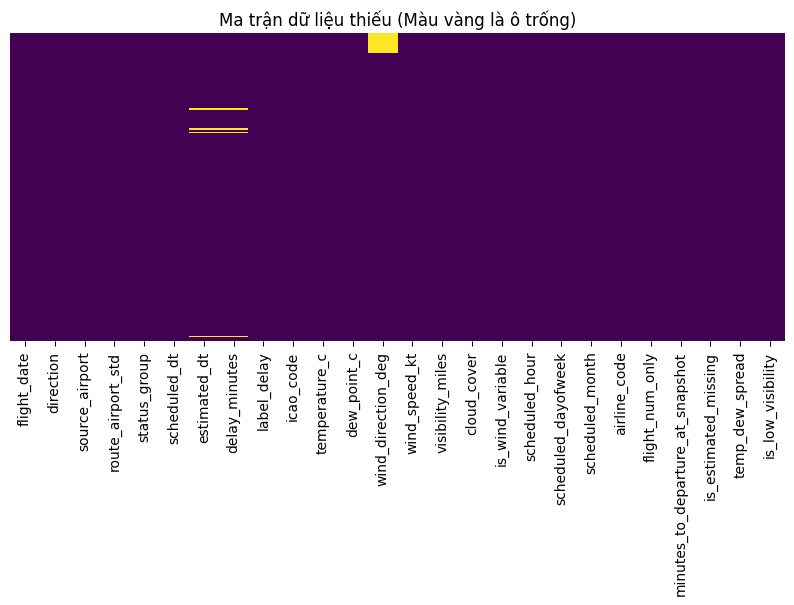

In [14]:
missing_delay = df_train[df_train['delay_minutes'].isnull()]
print("--- Phân tích dòng thiếu delay_minutes ---")
print(missing_delay['status_group'].value_counts())

# Trực quan hóa ma trận dữ liệu thiếu (để xem các cột có thiếu cùng lúc không)
plt.figure(figsize=(10, 4))
sns.heatmap(df_train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Ma trận dữ liệu thiếu (Màu vàng là ô trống)')
plt.show()

Các dòng `deplay_minutes` bị thiếu nhưng đều có `status_raw` là `Đúng giờ` hoặc `Đã hạ cánh` -> Có thể là bot chưa cập nhật được dữ liệu về các chuyến bay này cho nên bị thiếu `deplay_minutes` ở các dòng này. Không ảnh hưởng quá lớn đến dataset

### Phân tích Phân phối và Độ lệch

Skewness của delay_minutes: 9.17
Skewness của temperature_c: -0.43
Skewness của wind_speed_kt: -0.68
Skewness của visibility_miles: -2.36
Skewness của scheduled_hour: -0.14


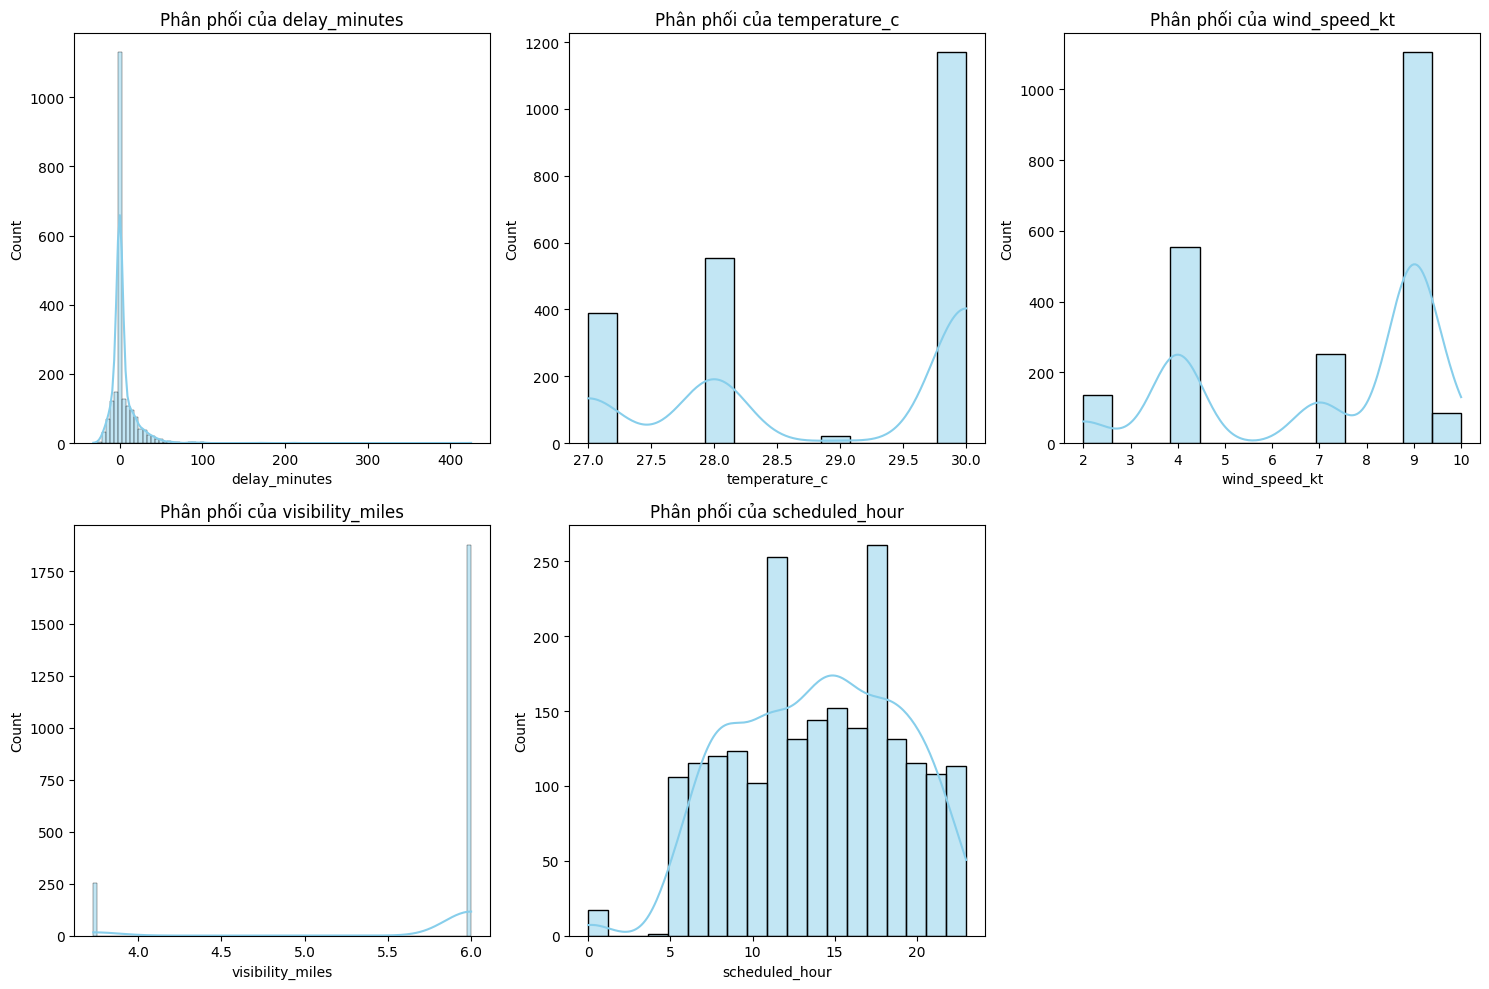

In [15]:
# Danh sách các cột số cần kiểm tra
num_cols = ['delay_minutes', 'temperature_c', 'wind_speed_kt', 'visibility_miles', 'scheduled_hour']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_train[col], kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
    # Tính độ lệch (Skewness)
    print(f"Skewness của {col}: {df_train[col].skew():.2f}")

plt.tight_layout()
plt.show()

`delay_minutes`: Log Transform + RobustScaler (để giảm ảnh hưởng Outliers).

`visibility_miles`: Cân nhắc Binning (chia nhóm: Tốt / Trung bình / Xấu) vì dữ liệu quá lệch.

`scheduled_hour` : Giữ nguyên hoặc dùng Sine/Cosine Transform (để máy hiểu 23h và 0h là gần nhau).

`temperature_c` : Standard Scaling.

## Phân tích Đa biến

### Phân tích tương quan

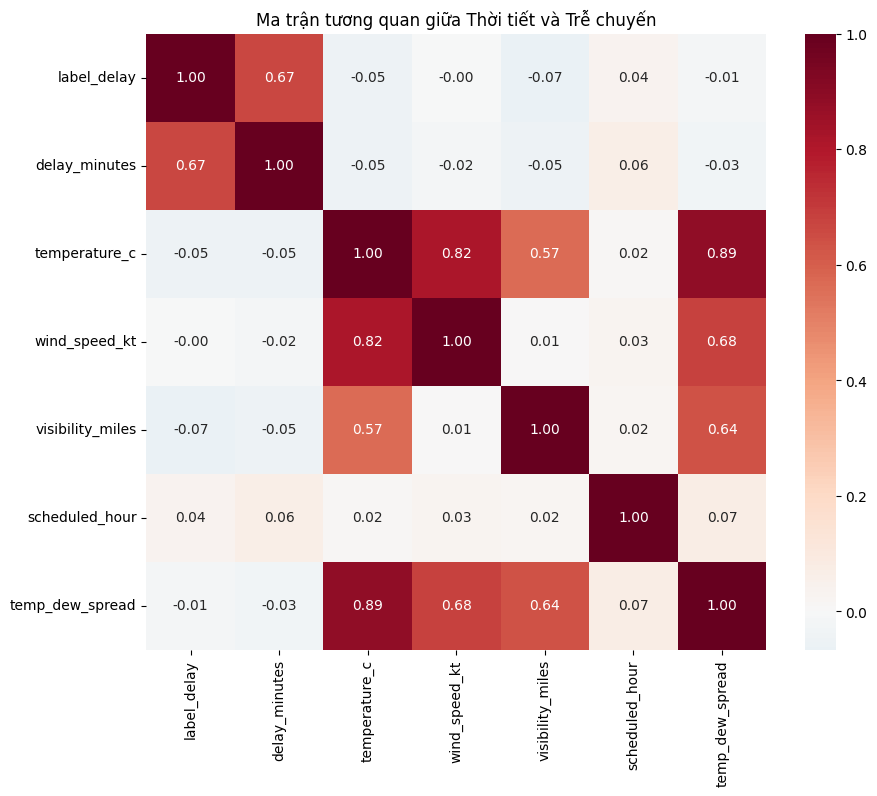

In [16]:
# Chọn các cột số quan trọng
corr_cols = ['label_delay', 'delay_minutes', 'temperature_c', 'wind_speed_kt', 
             'visibility_miles', 'scheduled_hour', 'temp_dew_spread']

plt.figure(figsize=(10, 8))
correlation_matrix = df_train[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Ma trận tương quan giữa Thời tiết và Trễ chuyến')
plt.show()

**Nhận xét:**
- Về tính dự báo: Biến `delay_minutes` đóng vai trò quan trọng nhất trong việc định hình nhãn `label_delay` (0.67) (do biến `label_delay` được feature engineering từ `delay_minutes`). Các biến thời tiết như sức gió và tầm nhìn thể hiện mức độ tương quan tuyến tính rất thấp (< 0.1), cho thấy trễ chuyến là một hiện tượng đa yếu tố và không phụ thuộc cực đoan vào điều kiện thời tiết tại thời điểm snapshot.

- Về chất lượng tính năng: Phát hiện hiện tượng đa cộng tuyến mạnh giữa temperature_c và temp_dew_spread (0.88). Để tối ưu hóa mô hình, khuyến nghị chỉ giữ lại một trong hai đặc trưng này.

### Các Phát hiện Bất thường

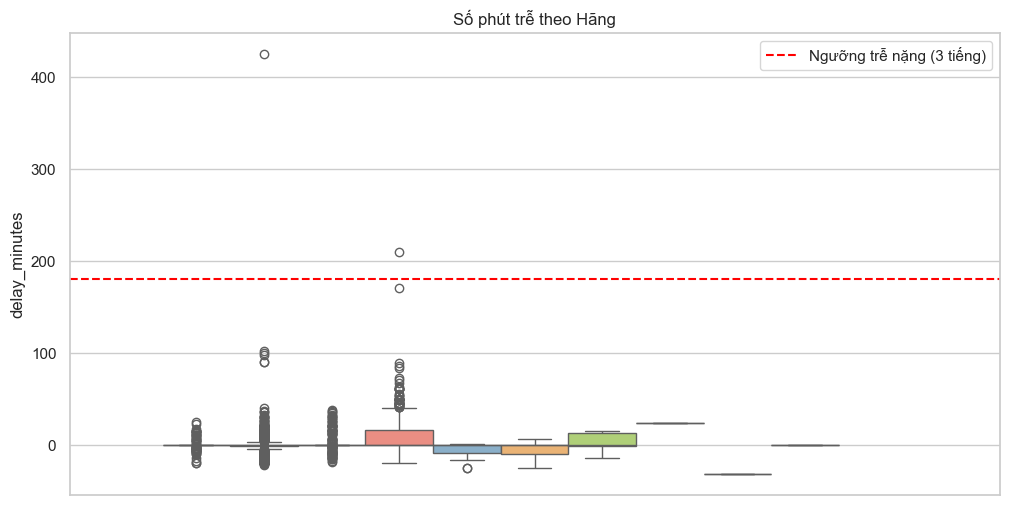

Top 5 chuyến bay trễ nhất
|      | airline_code   |   flight_num_only |   delay_minutes | status_group   |
|-----:|:---------------|------------------:|----------------:|:---------------|
| 1341 | VN             |              7207 |             425 | departed       |
|  138 | VJ             |              1504 |             210 | other          |
|  196 | VJ             |               528 |             170 | other          |
| 1376 | VN             |               212 |             102 | landed         |
| 1227 | VN             |               209 |             100 | departed       |
| 1434 | VN             |               262 |              98 | landed         |
| 1046 | VN             |               221 |              90 | unknown        |
| 1577 | VN             |               221 |              90 | unknown        |
|  925 | VJ             |               774 |              89 | landed         |
| 1333 | VJ             |              1505 |              85 | departed       |


In [57]:
plt.figure(figsize=(12, 6))

# Vẽ Boxplot cho số phút trễ theo Hãng hàng không
sns.boxplot(hue='airline_code', y='delay_minutes', data=df_train, palette='Set3', legend=False)
plt.axhline(y=180, color='red', linestyle='--', label='Ngưỡng trễ nặng (3 tiếng)')
plt.title('Số phút trễ theo Hãng')
plt.legend()
plt.show()

# Lọc ra danh sách 5 chuyến bay trễ "kinh khủng" nhất để inspect
outliers_top = df_train.nlargest(10, 'delay_minutes')[['airline_code', 'flight_num_only','delay_minutes', 'status_group']]
print("Top 5 chuyến bay trễ nhất")
print(outliers_top.to_markdown())

**Các chuyến bay có thời tiết tốt nhưng bị label là trễ chuyến**

In [65]:
# Lọc các chuyến trễ nặng trong điều kiện thời tiết tốt
operational_anomalies = df_train[
    (df_train['label_delay'] == 1) & 
    (df_train['visibility_miles'] >= 6) & 
    (df_train['wind_speed_kt'] < 10)
]
print(f"Số lượng bất thường vận hành: {len(operational_anomalies)}")

Số lượng bất thường vận hành: 236


In [66]:
print(operational_anomalies['airline_code'].value_counts())

airline_code
VJ    166
VN     38
9G     24
QH      4
CH      2
HA      2
Name: count, dtype: int64


In [ ]:
# Kiểm tra ngày và giờ của các ca bất thường
print(operational_anomalies[['flight_date', 'scheduled_hour', 'delay_minutes', 'label_delay']])

     flight_date  scheduled_hour  delay_minutes  label_delay
2     2026-04-09              13           20.0            1
7     2026-04-09              12           35.0            1
12    2026-04-09              10           50.0            1
18    2026-04-09               9           40.0            1
19    2026-04-09               9           20.0            1
...          ...             ...            ...          ...
2029  2026-04-09              22           15.0            1
2035  2026-04-09              23           40.0            1
2038  2026-04-09              23           40.0            1
2039  2026-04-09              22           35.0            1
2045  2026-04-09              22           15.0            1

[236 rows x 4 columns]


**Nhận xét:** Ta thấy ở điều kiện thời tiết thuận lời như `visibility_miles >= 6` và `wind_speed_kt <=10` thì có đến 236 trường hợp chuyến bay bị đánh dấu là trễ

$\rightarrow$ Không thể nhận định là các yếu tố thời tiết là nhân tố duy nhất dẫn đến việc các chuyến bay bị trễ mà còn do các cơ sở hạ tầng, việc trễ chuyến dây chuyền làm cho toàn bộ hệ thống bị quá tải.

### Phân tích xu hướng theo thời gian

**Tỉ lệ trễ theo các ngày thực tế**

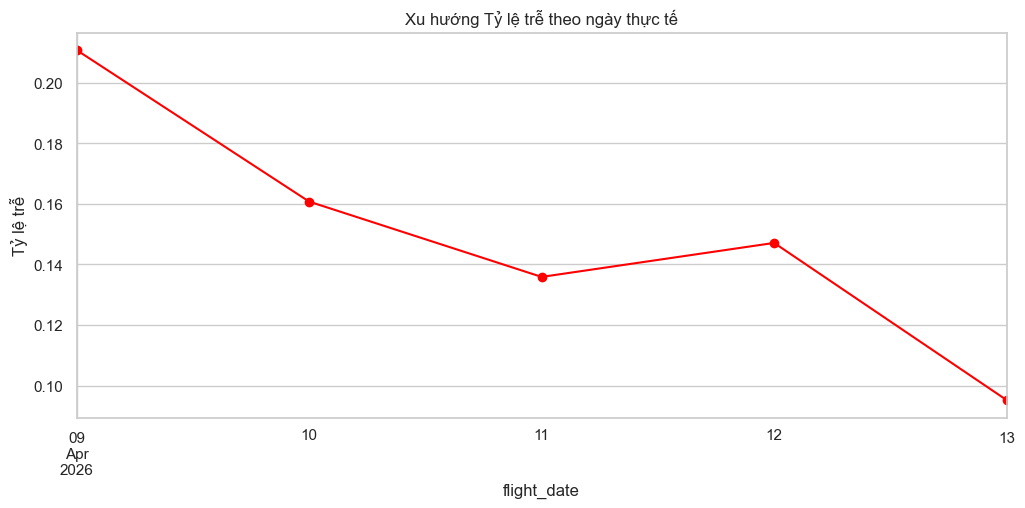

In [42]:
# Chuyển flight_date về datetime và vẽ trend theo ngày
df_train['flight_date'] = pd.to_datetime(df_train['flight_date'])
daily_trend = df_train.groupby('flight_date')['label_delay'].mean()

plt.figure(figsize=(12, 5))
daily_trend.plot(marker='o', color='red')
plt.title('Xu hướng Tỷ lệ trễ theo ngày thực tế')
plt.ylabel('Tỷ lệ trễ')
plt.grid(True)

**Tỉ lệ trễ theo các giờ trong ngày**

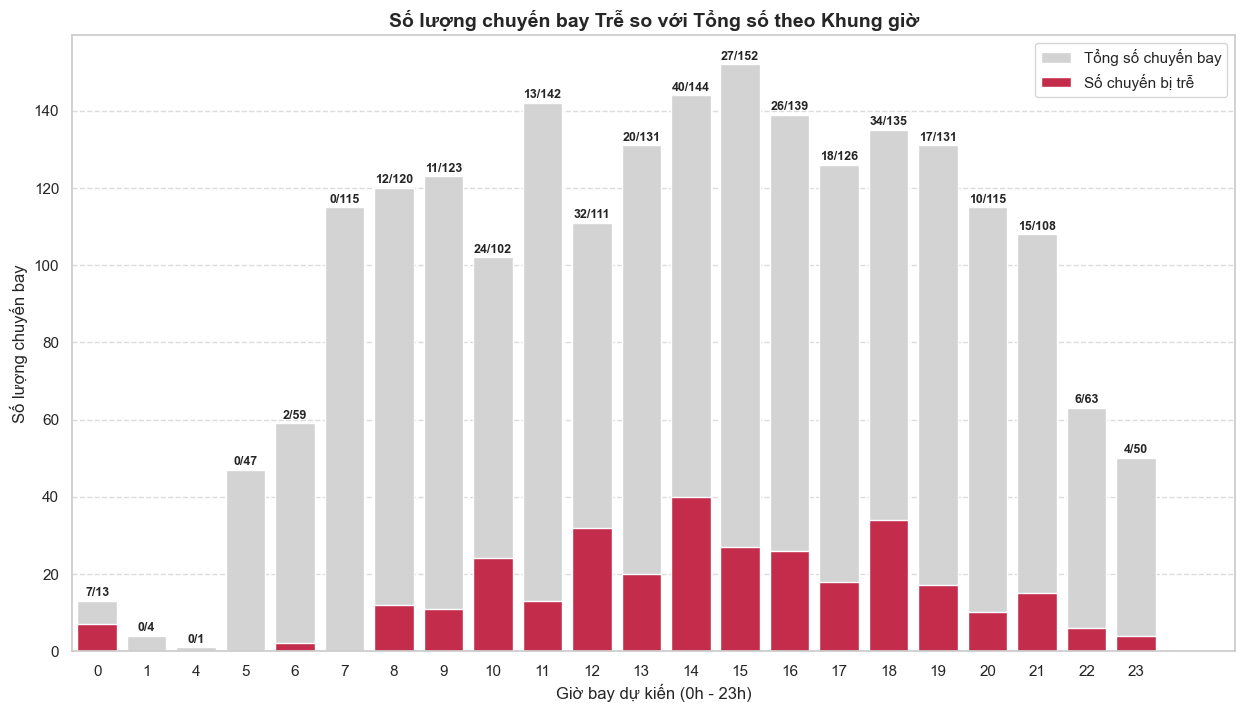

In [28]:
hourly_counts = df_train.groupby(['scheduled_hour', 'label_delay']).size().unstack(fill_value=0)
hourly_counts.columns = ['Đúng giờ', 'Trễ']
hourly_counts['Tổng số'] = hourly_counts['Đúng giờ'] + hourly_counts['Trễ']

# 2. Vẽ biểu đồ
plt.figure(figsize=(15, 8))

# Vẽ cột "Tổng số" trước (màu nhạt hơn)
sns.barplot(x=hourly_counts.index, y=hourly_counts['Tổng số'], color='lightgrey', label='Tổng số chuyến bay')

# Vẽ chồng cột "Trễ" lên trên (màu đậm/nổi bật)
sns.barplot(x=hourly_counts.index, y=hourly_counts['Trễ'], color='crimson', label='Số chuyến bị trễ')

# 3. Thêm nhãn số lượng trên đầu mỗi cột để dễ quan sát
for i, total in enumerate(hourly_counts['Tổng số']):
    delay = hourly_counts['Trễ'].iloc[i]
    # Hiển thị: Số trễ / Tổng số
    plt.text(i, total + 0.5, f'{delay}/{total}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Số lượng chuyến bay Trễ so với Tổng số theo Khung giờ', fontsize=14, fontweight='bold')
plt.xlabel('Giờ bay dự kiến (0h - 23h)')
plt.ylabel('Số lượng chuyến bay')
plt.legend()
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Tỉ lệ trễ theo các ngày trong tuần**

C:\Users\vnviv\AppData\Local\Temp\ipykernel_2960\1101216871.py:20: RuntimeWarning: invalid value encountered in scalar divide
  rate = (delay / total) * 100


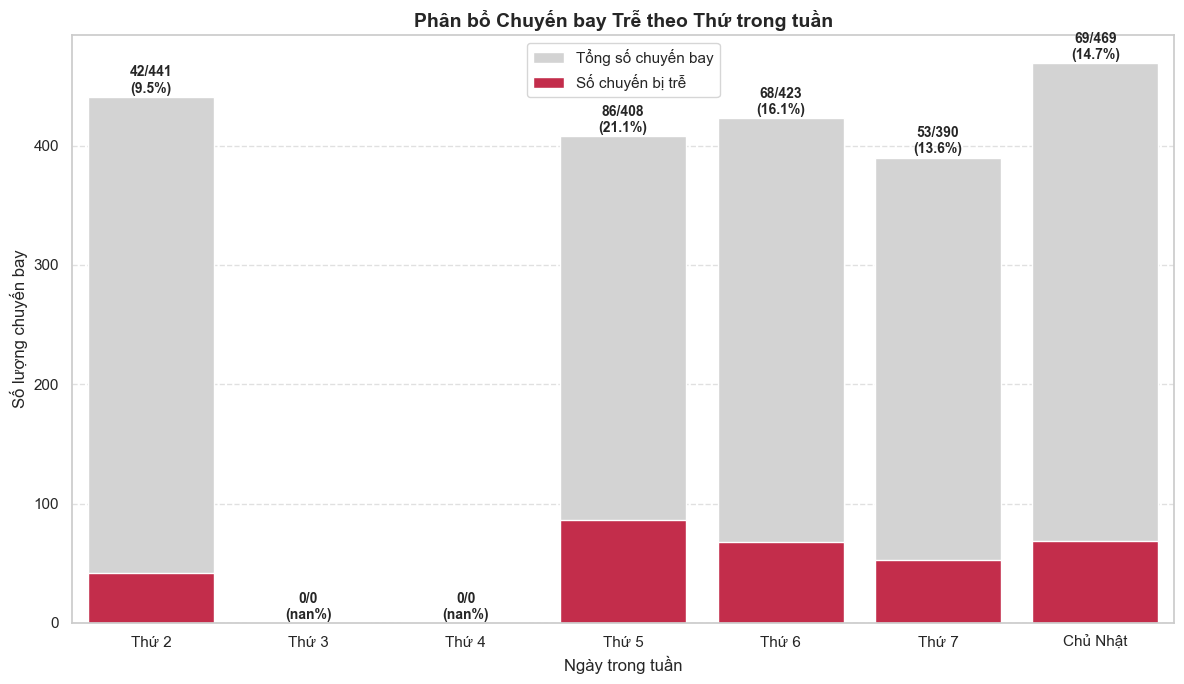

In [35]:
weekly_counts = df_train.groupby(['scheduled_dayofweek', 'label_delay']).size().unstack(fill_value=0)
weekly_counts.columns = ['Đúng giờ', 'Trễ']
weekly_counts['Tổng số'] = weekly_counts['Đúng giờ'] + weekly_counts['Trễ']
weekly_counts = weekly_counts.reindex(range(7), fill_value=0)

day_labels = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 7))

# Vẽ cột "Tổng số" (Màu xám nhạt làm nền)
sns.barplot(x=weekly_counts.index, y=weekly_counts['Tổng số'], color='lightgrey', label='Tổng số chuyến bay')

# Vẽ chồng cột "Trễ" (Màu cam hoặc đỏ để nhấn mạnh)
sns.barplot(x=weekly_counts.index, y=weekly_counts['Trễ'], color='crimson', label='Số chuyến bị trễ')

# 3. Thêm nhãn số lượng và Tỷ lệ % trên đầu mỗi cột
for i, total in enumerate(weekly_counts['Tổng số']):
    delay = weekly_counts['Trễ'].iloc[i]
    rate = (delay / total) * 100
    # Hiển thị: Số trễ / Tổng số (Tỷ lệ %)
    plt.text(i, total + 1, f'{delay}/{total}\n({rate:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Phân bổ Chuyến bay Trễ theo Thứ trong tuần', fontsize=14, fontweight='bold')
plt.xlabel('Ngày trong tuần')
plt.ylabel('Số lượng chuyến bay')
plt.xticks(ticks=range(7), labels=day_labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

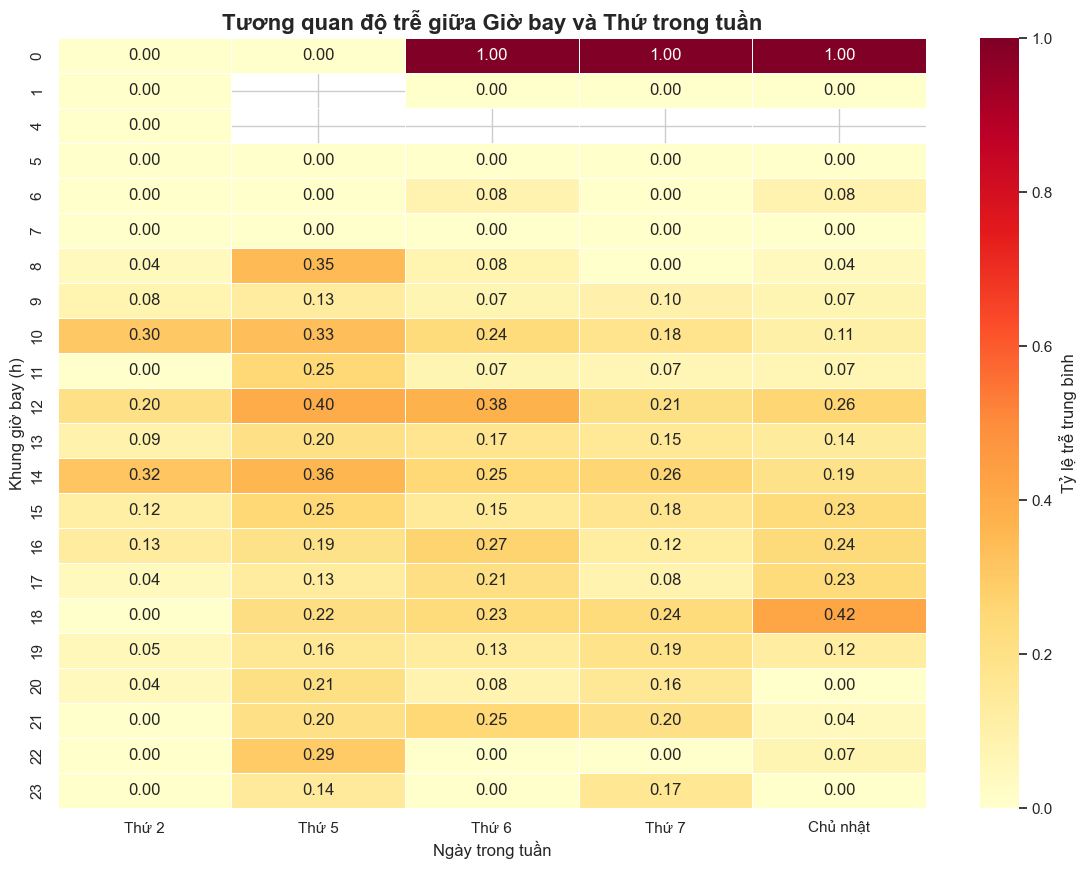

In [58]:
heatmap_data = df_train.groupby(['scheduled_hour', 'scheduled_dayofweek'])['label_delay'].mean().unstack()

day_map = {
    0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 
    3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ nhật'
}

heatmap_data = heatmap_data.rename(columns=day_map)

plt.figure(figsize=(14, 10))

# Vẽ heatmap
sns.heatmap(heatmap_data, 
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            linewidths=.5,
            cbar_kws={'label': 'Tỷ lệ trễ trung bình'})

# Thêm tiêu đề và nhãn
plt.title('Tương quan độ trễ giữa Giờ bay và Thứ trong tuần', fontsize=16, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Khung giờ bay (h)', fontsize=12)

plt.show()

**Nhận xét:**
Xu hướng tuyến tính theo thời gian trong ngày:
- Buổi sáng (5h - 9h): Là khoảng thời gian "sạch" nhất. Tỷ lệ trễ gần như bằng 0. Đây là lúc hệ thống vừa khởi động sau đêm, chưa bị ảnh hưởng bởi các sai số vận hành trước đó.

- Buổi trưa & Chiều (10h - 14h): Độ trễ bắt đầu xuất hiện và đạt đỉnh đầu tiên vào lúc 14h. Đây là thời điểm "nóng" cả về mật độ bay lẫn thời tiết (nhiệt độ cao nhất, dễ có dông nhiệt).

- Buổi tối (18h): Đỉnh thứ hai xuất hiện. Theo Heatmap, đặc biệt là Chủ nhật lúc 18h (0.42), đây là sự kết hợp giữa áp lực vận hành cuối ngày và lưu lượng khách tăng đột biến.

Tỉ lệ trễ ngày thứ 5:
- Heatmap chỉ ra rằng vào Thứ 5, độ trễ không chỉ tập trung vào giờ cao điểm mà nó lan rộng ra cả ngày (từ 8h sáng đã bắt đầu có màu cam 0.35).

Bất thường tại khung giờ 0h
- Tỉ lệ trễ các chuyến 0h các ngày Thứ 6, 7, CN là **1.00**
    - Đây không phải là do vận hành tại chỗ lúc 0h, mà là hệ quả của tất cả các chuyến trễ từ chiều và tối chưa xử lý xong, bị dồn lại đến tận nửa đêm. Trong phân tích chuỗi thời gian, đây là hiện tượng "trễ dây chuyền" đạt mức cực đại.

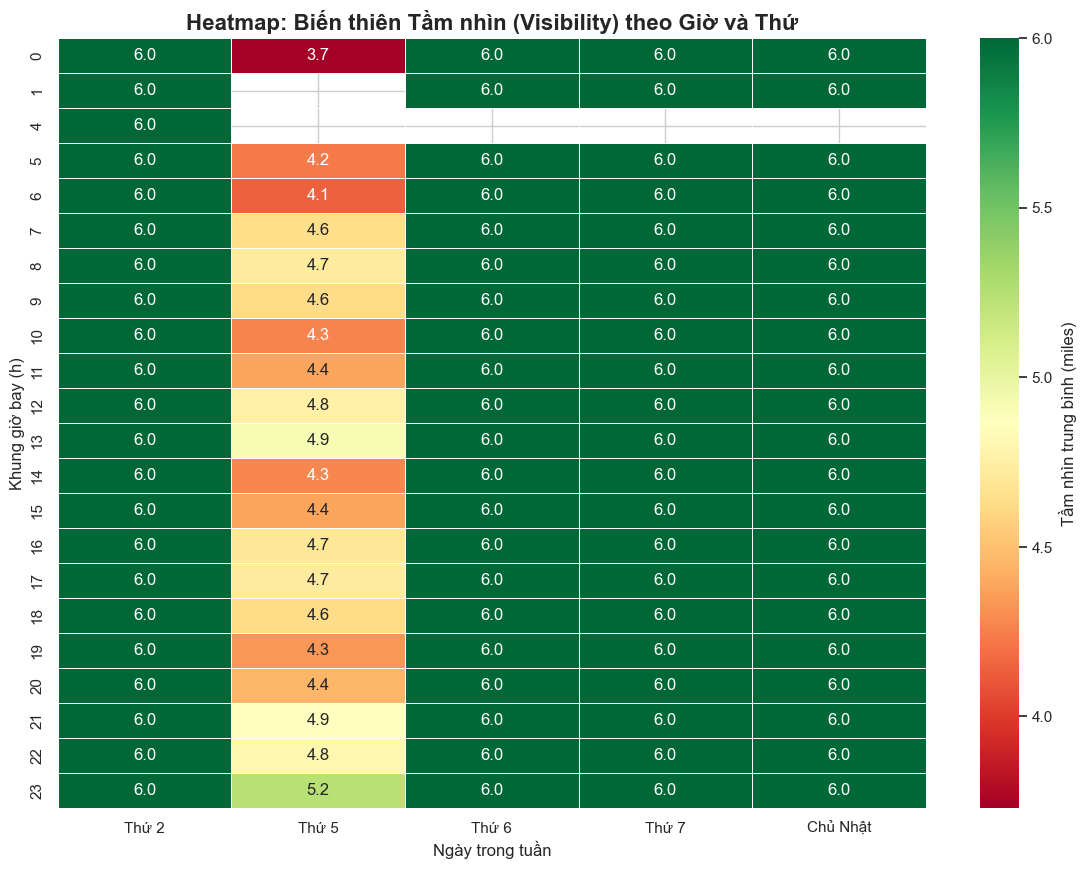

In [36]:
visibility_heatmap = df_train.groupby(['scheduled_hour', 'scheduled_dayofweek'])['visibility_miles'].mean().unstack()

# 2. Mapping lại nhãn ngày để khớp với dữ liệu thực tế (tránh lỗi Length mismatch)
day_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
visibility_heatmap = visibility_heatmap.rename(columns=day_map)

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 10))

# Sử dụng bảng màu RdYlGn (Red-Yellow-Green) 
# Màu Đỏ (Thấp) = Tầm nhìn kém (Nguy hiểm)
# Màu Xanh (Cao) = Tầm nhìn tốt (An toàn)
sns.heatmap(visibility_heatmap, 
            annot=True, 
            fmt=".1f", 
            cmap="RdYlGn", 
            linewidths=.5,
            cbar_kws={'label': 'Tầm nhìn trung bình (miles)'})

plt.title('Heatmap: Biến thiên Tầm nhìn (Visibility) theo Giờ và Thứ', fontsize=16, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Khung giờ bay (h)', fontsize=12)

plt.show()

$\Rightarrow$ Dựa vào heatmap về `visibility_miles` ở Thứ 5 đã bị chi phối về tầm nhìn khiến cho tỉ lệ ở trễ ở Thứ 5 này tăng hơn hẳn so với các ngày còn lại. Ta có thể kết luận là `visibility_miles` có ảnh hưởng đến việc trễ chuyến. Nhưng đây cũng là một điểm bất thường vì các thứ khác đều ở mức khá đẹp là **6.0**

In [ ]:
from scipy.stats import ttest_ind

low_vis = df_train[df_train['visibility_miles'] < 5]['delay_minutes']
high_vis = df_train[df_train['visibility_miles'] >= 5]['delay_minutes']

t_stat, p_val = ttest_ind(low_vis, high_vis, nan_policy='omit')
print(f"P-value: {p_val}")

P-value: 0.026990507913304488


**Nhận xét** Thực hiện T-test về việc `visibility_miles` có thật sự ảnh hưởng đến thời gian bay? -> Câu trả lời là có do P_value < 0.05

### So sánh biến mục tiêu với các biến thành phần

**So sánh `airline_code` với `label_delay`**

In [72]:
airline_check = df_train.groupby('airline_code').agg(
    total_flight=('label_delay', 'count'),
    delay_rate=('label_delay', 'mean')
).reset_index()

print(airline_check.sort_values(by='delay_rate', ascending=False))

   airline_code  total_flight  delay_rate
6            HA             2    1.000000
8            VJ           754    0.286472
4            CH             9    0.222222
2            9G           234    0.141026
9            VN           885    0.065537
7            QH           115    0.060870
0            0V             2    0.000000
1            3S             1    0.000000
3            BL            76    0.000000
5            FX             1    0.000000
10           VU            52    0.000000


In [73]:
# Lọc riêng dữ liệu của VJ
vj_df = df_train[df_train['airline_code'] == 'VJ']

# Tính tỷ lệ trễ của VJ khi trời đẹp
vj_good_weather = vj_df[(vj_df['visibility_miles'] >= 5) & (vj_df['wind_speed_kt'] <= 10)]
vj_bad_weather = vj_df[(vj_df['visibility_miles'] < 5) | (vj_df['wind_speed_kt'] > 10)]

print(f"Tỷ lệ trễ VJ khi trời ĐẸP: {vj_good_weather['label_delay'].mean()*100:.2f}%")
print(f"Tỷ lệ trễ VJ khi trời XẤU: {vj_bad_weather['label_delay'].mean()*100:.2f}%")

Tỷ lệ trễ VJ khi trời ĐẸP: 27.76%
Tỷ lệ trễ VJ khi trời XẤU: 35.71%


**Nhận xét:** Mặc dù biến thời tiết có tác động đến độ trễ chung, nhưng phân tích sâu về hãng VJ cho thấy yếu tố vận hành mới là nguyên nhân chính dẫn đến tỉ lệ trễ chuyến của của hãng.

**Tỉ lệ trễ của 2 hãng `VN` và `VJ` theo xu hướng**

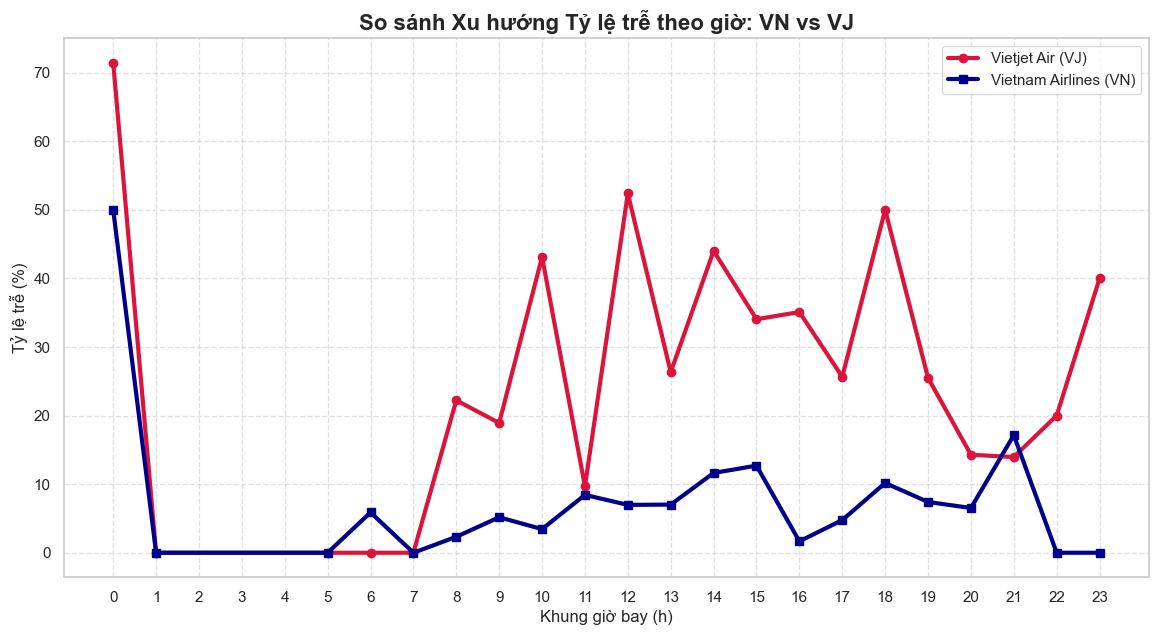

In [76]:
vj_vn_df = df_train[df_train['airline_code'].isin(['VJ', 'VN'])]

# 2. Tính tỷ lệ trễ theo giờ cho từng hãng
hourly_comparison = vj_vn_df.groupby(['scheduled_hour', 'airline_code'])['label_delay'].mean().unstack() * 100

# 3. Vẽ biểu đồ đường để thấy sự khác biệt về xu hướng
plt.figure(figsize=(14, 7))

# Vẽ đường cho VJ
plt.plot(hourly_comparison.index, hourly_comparison['VJ'], marker='o', linewidth=3, color='crimson', label='Vietjet Air (VJ)')
# Vẽ đường cho VN
plt.plot(hourly_comparison.index, hourly_comparison['VN'], marker='s', linewidth=3, color='darkblue', label='Vietnam Airlines (VN)')

# Thêm các chi tiết biểu đồ
plt.title('So sánh Xu hướng Tỷ lệ trễ theo giờ: VN vs VJ', fontsize=16, fontweight='bold')
plt.xlabel('Khung giờ bay (h)', fontsize=12)
plt.ylabel('Tỷ lệ trễ (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [78]:
night_flights = df_train[(df_train['scheduled_hour'] >= 12) & (df_train['scheduled_hour'] <= 18)]
vj_contribution = night_flights[night_flights['label_delay'] == 1]['airline_code'].value_counts(normalize=True) * 100

print("Tỷ lệ đóng góp vào các ca trễ từ 12h-18h:")
print(vj_contribution)

Tỷ lệ đóng góp vào các ca trễ từ 12h-18h:
airline_code
VJ    69.035533
VN    15.228426
9G    12.182741
QH     2.538071
CH     1.015228
Name: proportion, dtype: float64


**Nhận xét:** Điều này cho thấy rõ số chuyến trễ của hãng `VJ` ảnh hưởng rất lớn đối với tỉ lệ trễ theo xu hướng chung. Không phải do thời tiết xấu mà đa phần sẽ là do việc sắp xếp lịch, sự trễ theo dây chuyền và việc có quá nhiều lịch bay khiến cho hãng `VJ` bị quá tải dẫn đến trễ nhiều.